##### English

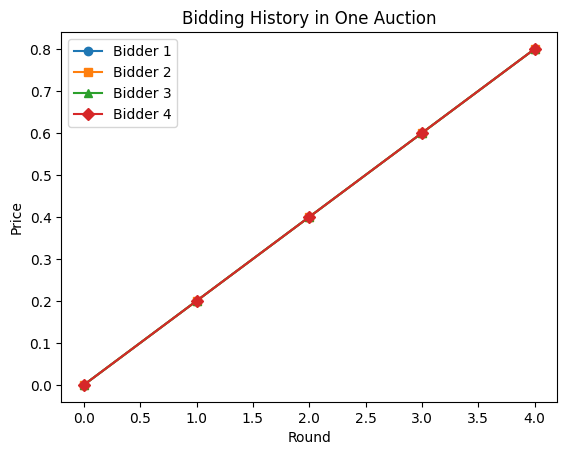

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

class QLearner:
    def __init__(self, alpha=0.1, gamma=1, epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}  # Q-value table initialized as an empty dictionary

    def get_q(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def update_q(self, state, action, reward, next_state, done):
        if done:
            max_next_q = 0  # No future reward after auction ends
        else:
            max_next_q = max([self.get_q(next_state, a) for a in [0, 1]])
        
        self.q_table[(state, action)] = self.get_q(state, action) + self.alpha * (reward + self.gamma * max_next_q - self.get_q(state, action))

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.choice([0, 1])  # Exploration: Random choice between stay (1) or drop out (0)
        else:
            q_stay = self.get_q(state, 1)
            q_drop = self.get_q(state, 0)
            return 1 if q_stay >= q_drop else 0  # Exploitation: Choose the action with higher Q-value

# Auction Setup
class EnglishAuction:
    def __init__(self, n_bidders=4, rounds=5, price_step=0.2, granularity=6):
        self.n_bidders = n_bidders
        self.rounds = rounds
        self.price_step = price_step
        self.granularity = granularity
        self.learners = [QLearner() for _ in range(n_bidders)]
        self.valuations = np.round(np.random.uniform(0, 1, n_bidders) * granularity) / granularity  # Valuations for each bidder
        self.states = [(self.valuations[i], 0, self.n_bidders-1) for i in range(n_bidders)]  # Initial states (v, t, n)
        self.bidding_history = {i: [] for i in range(self.n_bidders)}  # Bidding history for each bidder

    def run_one_auction(self):
        # Reset bidding history for one auction
        self.bidding_history = {i: [] for i in range(self.n_bidders)}
        self.valuations = np.round(np.random.uniform(0, 1, self.n_bidders) * self.granularity) / self.granularity
        self.states = [(self.valuations[i], 0, self.n_bidders-1) for i in range(self.n_bidders)]
        active_bidders = list(range(self.n_bidders))
        price = 0
        for t in range(self.rounds):
            if len(active_bidders) == 1:
                break  # Only one bidder left

            next_active_bidders = []
            for i in active_bidders:
                state = self.states[i]
                action = self.learners[i].select_action(state)
                
                if action == 1:  # Stay in the auction
                    next_active_bidders.append(i)
                    self.bidding_history[i].append(price)  # Record the bid
                else:  # Drop out
                    reward = -(price - self.valuations[i])
                    self.learners[i].update_q(state, 0, reward, state, done=True)
                    self.bidding_history[i].append(price)  # Record the bid at which they drop out

            if len(next_active_bidders) == 1:
                winner = next_active_bidders[0]
                reward = price - self.valuations[winner]
                self.learners[winner].update_q(self.states[winner], 1, reward, self.states[winner], done=True)
                break
            
            # Update price and states for next round
            price += self.price_step
           
            for i in next_active_bidders:
                self.states[i] = (self.valuations[i], t + 1, len(next_active_bidders) - 1)

            active_bidders = next_active_bidders

        # If more than one bidder is still in the auction after 5 rounds, break ties randomly
        if len(active_bidders) > 1:
            winner = random.choice(active_bidders)
            reward = price - self.valuations[winner]
            self.learners[winner].update_q(self.states[winner], 1, reward, self.states[winner], done=True)
            for i in active_bidders:
                if i != winner:
                    self.learners[i].update_q(self.states[i], 1, 0, self.states[i], done=True)

    def plot_bidding_history(self):
        rounds = list(range(self.rounds))
        markers = ['o', 's', '^', 'D']  # Different markers for each bidder
        for i in range(self.n_bidders):
            # Only plot bids for rounds where the bidder was active
            plt.plot(range(len(self.bidding_history[i])), self.bidding_history[i], label=f"Bidder {i+1}", marker=markers[i])
        plt.xlabel("Round")
        plt.ylabel("Price")
        plt.title("Bidding History in One Auction")
        plt.legend()
        plt.show()

# Running the auction simulation
auction = EnglishAuction()
auction.run_one_auction()  # Runs only one auction
auction.plot_bidding_history()  # Plots bidding history for one auction


##### Korean

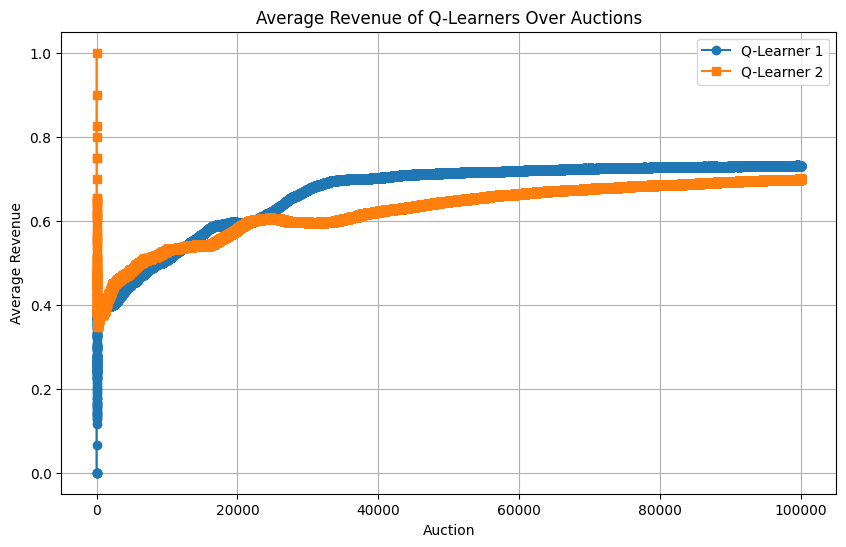

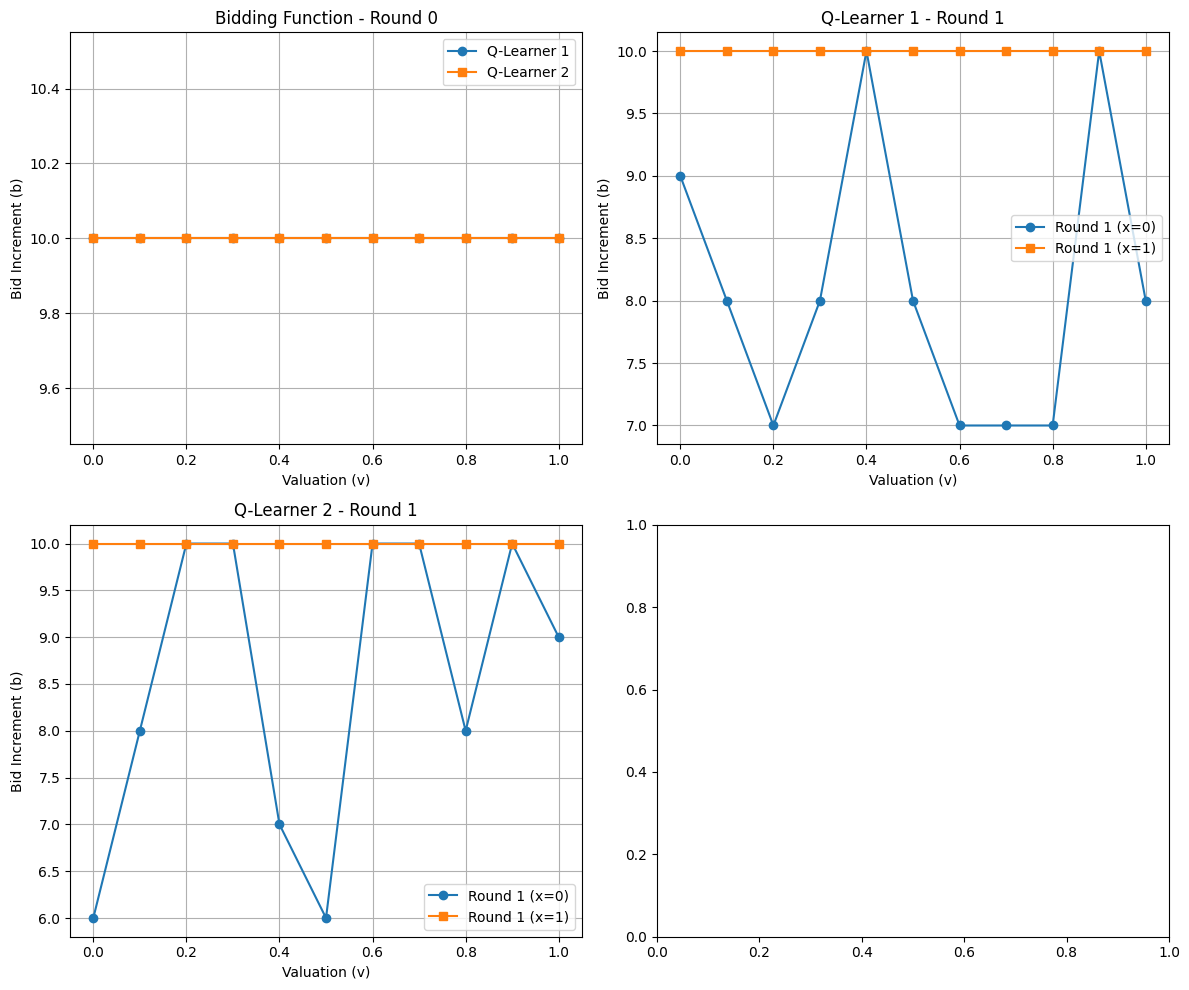

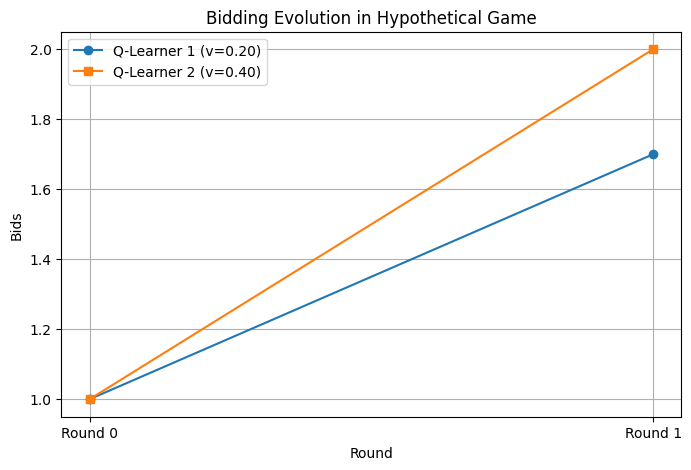

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

class QLearner:
    def __init__(self, alpha=0.01, gamma=0.999, epsilon=0.99, epsilon_min=0.01, epsilon_decay=0.9999, num_actions=11):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table_round_0 = {}  # Q-table for round 0 (state: v)
        self.q_table_round_1 = {}  # Q-table for round 1 (state: v, x)
        self.num_actions = num_actions

    def get_q(self, table, state, action):
        return table.get((state, action), 0.0)

    def update_q(self, table, state, action, reward, next_state, done, gamma):
        max_next_q = 0 if done else max(self.get_q(table, next_state, a) for a in range(self.num_actions))
        table[(state, action)] = self.get_q(table, state, action) + self.alpha * (reward + gamma * max_next_q - self.get_q(table, state, action))

    def select_action(self, table, state):
        if np.random.rand() < self.epsilon:
            return random.choice(range(self.num_actions))
        else:
            return np.argmax([self.get_q(table, state, a) for a in range(self.num_actions)])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

class KoreanAuction:
    def __init__(self, K=11):
        self.K = K
        self.q_learner1 = QLearner()
        self.q_learner2 = QLearner()
        self.val_granularity = np.linspace(0, 1, K)
        self.bid_granularity = np.linspace(0, 1, K)

    def run_one_auction(self):
        v1 = np.random.choice(self.val_granularity)  # Valuation for Q-learner 1
        v2 = np.random.choice(self.val_granularity)  # Valuation for Q-learner 2
        current_bid_1 = 0
        current_bid_2 = 0
        last_highest_bidder = -1

        # Round 0: state is just v (valuation)
        state_q_round_0_1 = (v1)
        action_q_round_0_1 = self.q_learner1.select_action(self.q_learner1.q_table_round_0, state_q_round_0_1)
        current_bid_1 += self.bid_granularity[action_q_round_0_1]

        state_q_round_0_2 = (v2)
        action_q_round_0_2 = self.q_learner2.select_action(self.q_learner2.q_table_round_0, state_q_round_0_2)
        current_bid_2 += self.bid_granularity[action_q_round_0_2]

        if current_bid_1 > current_bid_2:
            last_highest_bidder = 1
        elif current_bid_2 > current_bid_1:
            last_highest_bidder = 0
        else:
            last_highest_bidder = random.choice([0, 1])

        # Round 1: state is (v, x) where x is whether Q-learner 1 had the highest bid in the last round
        state_q_round_1_1 = (v1, last_highest_bidder)
        action_q_round_1_1 = self.q_learner1.select_action(self.q_learner1.q_table_round_1, state_q_round_1_1)
        current_bid_1 += self.bid_granularity[action_q_round_1_1]

        state_q_round_1_2 = (v2, 1 - last_highest_bidder)
        action_q_round_1_2 = self.q_learner2.select_action(self.q_learner2.q_table_round_1, state_q_round_1_2)
        current_bid_2 += self.bid_granularity[action_q_round_1_2]

        if current_bid_1 > current_bid_2:
            winner = 1
        elif current_bid_2 > current_bid_1:
            winner = 0
        else:
            winner = last_highest_bidder

        reward_1 = (current_bid_1 - v1) if winner == 1 else 0
        reward_2 = (current_bid_2 - v2) if winner == 0 else 0

        # Update Q-tables for each round
        self.q_learner1.update_q(self.q_learner1.q_table_round_0, state_q_round_0_1, action_q_round_0_1, reward_1, state_q_round_1_1, done=False, gamma=self.q_learner1.gamma)
        self.q_learner1.update_q(self.q_learner1.q_table_round_1, state_q_round_1_1, action_q_round_1_1, reward_1, None, done=True, gamma=0)

        self.q_learner2.update_q(self.q_learner2.q_table_round_0, state_q_round_0_2, action_q_round_0_2, reward_2, state_q_round_1_2, done=False, gamma=self.q_learner2.gamma)
        self.q_learner2.update_q(self.q_learner2.q_table_round_1, state_q_round_1_2, action_q_round_1_2, reward_2, None, done=True, gamma=0)

        self.q_learner1.decay_epsilon()
        self.q_learner2.decay_epsilon()

        return reward_1, reward_2

    def plot_bidding_function(self):
        v_values = self.val_granularity
        b_values = np.arange(self.K)

        # Round 0
        q_round_0_1 = [np.argmax([self.q_learner1.get_q(self.q_learner1.q_table_round_0, v, b) for b in b_values]) for v in v_values]
        q_round_0_2 = [np.argmax([self.q_learner2.get_q(self.q_learner2.q_table_round_0, v, b) for b in b_values]) for v in v_values]

        # Round 1
        q_round_1_1_x0 = [np.argmax([self.q_learner1.get_q(self.q_learner1.q_table_round_1, (v, 0), b) for b in b_values]) for v in v_values]
        q_round_1_1_x1 = [np.argmax([self.q_learner1.get_q(self.q_learner1.q_table_round_1, (v, 1), b) for b in b_values]) for v in v_values]

        q_round_1_2_x0 = [np.argmax([self.q_learner2.get_q(self.q_learner2.q_table_round_1, (v, 0), b) for b in b_values]) for v in v_values]
        q_round_1_2_x1 = [np.argmax([self.q_learner2.get_q(self.q_learner2.q_table_round_1, (v, 1), b) for b in b_values]) for v in v_values]

        fig, axs = plt.subplots(2, 2, figsize=(12, 10))

        # Plot Round 0 for both learners
        axs[0, 0].plot(v_values, q_round_0_1, label='Q-Learner 1', marker='o')
        axs[0, 0].plot(v_values, q_round_0_2, label='Q-Learner 2', marker='s')
        axs[0, 0].set_xlabel("Valuation (v)")
        axs[0, 0].set_ylabel("Bid Increment (b)")
        axs[0, 0].set_title("Bidding Function - Round 0")
        axs[0, 0].grid()
        axs[0, 0].legend()

        # Plot Round 1 for Q-Learner 1
        axs[0, 1].plot(v_values, q_round_1_1_x0, label='Round 1 (x=0)', marker='o')
        axs[0, 1].plot(v_values, q_round_1_1_x1, label='Round 1 (x=1)', marker='s')
        axs[0, 1].set_xlabel("Valuation (v)")
        axs[0, 1].set_ylabel("Bid Increment (b)")
        axs[0, 1].set_title("Q-Learner 1 - Round 1")
        axs[0, 1].grid()
        axs[0, 1].legend()

        # Plot Round 1 for Q-Learner 2
        axs[1, 0].plot(v_values, q_round_1_2_x0, label='Round 1 (x=0)', marker='o')
        axs[1, 0].plot(v_values, q_round_1_2_x1, label='Round 1 (x=1)', marker='s')
        axs[1, 0].set_xlabel("Valuation (v)")
        axs[1, 0].set_ylabel("Bid Increment (b)")
        axs[1, 0].set_title("Q-Learner 2 - Round 1")
        axs[1, 0].grid()
        axs[1, 0].legend()

        plt.tight_layout()
        plt.show()

    def plot_hypothetical_game(self):
        v1 = np.random.choice(self.val_granularity)  # Valuation for Q-learner 1
        v2 = np.random.choice(self.val_granularity)  # Valuation for Q-learner 2

        current_bid_1 = 0
        current_bid_2 = 0

        bids_1 = []
        bids_2 = []
        rounds = ["Round 0", "Round 1"]

        # Round 0
        state_q_round_0_1 = (v1)
        action_q_round_0_1 = self.q_learner1.select_action(self.q_learner1.q_table_round_0, state_q_round_0_1)
        current_bid_1 += self.bid_granularity[action_q_round_0_1]
        bids_1.append(current_bid_1)

        state_q_round_0_2 = (v2)
        action_q_round_0_2 = self.q_learner2.select_action(self.q_learner2.q_table_round_0, state_q_round_0_2)
        current_bid_2 += self.bid_granularity[action_q_round_0_2]
        bids_2.append(current_bid_2)

        # Round 1
        last_highest_bidder = 1 if current_bid_1 > current_bid_2 else 0
        state_q_round_1_1 = (v1, last_highest_bidder)
        action_q_round_1_1 = self.q_learner1.select_action(self.q_learner1.q_table_round_1, state_q_round_1_1)
        current_bid_1 += self.bid_granularity[action_q_round_1_1]
        bids_1.append(current_bid_1)

        state_q_round_1_2 = (v2, 1 - last_highest_bidder)
        action_q_round_1_2 = self.q_learner2.select_action(self.q_learner2.q_table_round_1, state_q_round_1_2)
        current_bid_2 += self.bid_granularity[action_q_round_1_2]
        bids_2.append(current_bid_2)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(rounds, bids_1, marker='o', label=f'Q-Learner 1 (v={v1:.2f})')
        ax.plot(rounds, bids_2, marker='s', label=f'Q-Learner 2 (v={v2:.2f})')
        ax.set_xlabel("Round")
        ax.set_ylabel("Bids")
        ax.set_title("Bidding Evolution in Hypothetical Game")
        ax.legend()
        ax.grid()
        plt.show()

    def plot_avg_revenue(self, num_auctions=1000):
        rewards_1 = []
        rewards_2 = []

        for _ in range(num_auctions):
            reward_1, reward_2 = self.run_one_auction()
            rewards_1.append(reward_1)
            rewards_2.append(reward_2)

        avg_revenue_1 = np.cumsum(rewards_1) / np.arange(1, len(rewards_1) + 1)
        avg_revenue_2 = np.cumsum(rewards_2) / np.arange(1, len(rewards_2) + 1)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(avg_revenue_1, label='Q-Learner 1', marker='o')
        ax.plot(avg_revenue_2, label='Q-Learner 2', marker='s')
        ax.set_xlabel("Auction")
        ax.set_ylabel("Average Revenue")
        ax.set_title("Average Revenue of Q-Learners Over Auctions")
        ax.legend()
        ax.grid()
        plt.show()

# Running the Korean auction simulation
auction = KoreanAuction()
auction.plot_avg_revenue(num_auctions=100000)
auction.plot_bidding_function()
auction.plot_hypothetical_game()

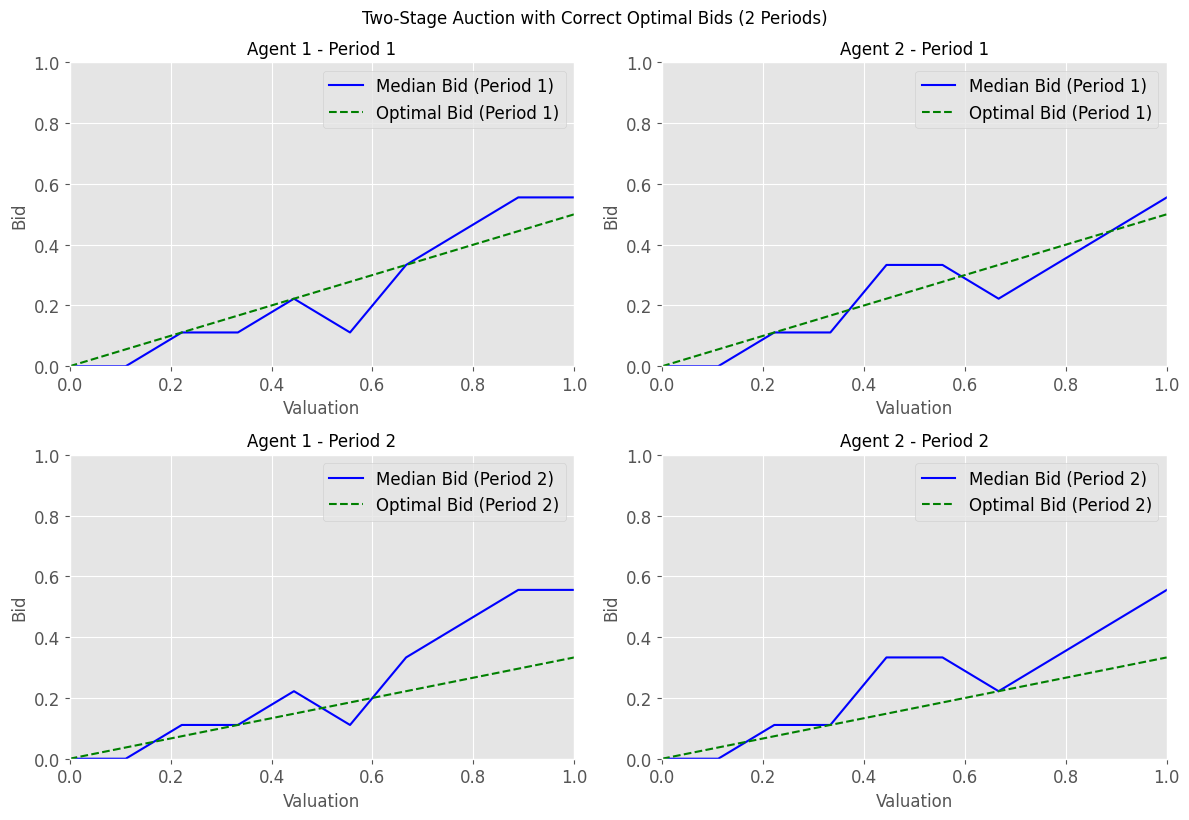

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33454)
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, epsilon=0.1, alpha=0.1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))  # Q-table for different valuation states
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def choose_action(self):
        valuation_state = self.state
        return np.random.choice(self.actions) if np.random.rand() < self.epsilon else self.actions[np.argmax(self.q_values[valuation_state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)


class TwoStageAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None, epsilon_reward=0.001):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.epsilon_reward = epsilon_reward
        self.profit_history = []

    def run_two_stage_auction(self):
        # Period 1
        for agent in self.agents:
            agent.refresh_valuation()
        bids_period1 = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner1_index, price1 = self.payment_rule(bids_period1)
        
        # Period 2
        bids_period2 = []
        for idx, agent in enumerate(self.agents):
            agent.state = agent.get_state(agent.valuation)  # State is only based on valuation
            bids_period2.append(max(self.price_floor, min(agent.choose_action(), self.price_ceiling)))
        winner2_index, price2 = self.payment_rule(bids_period2)

        # Update Q-values and rewards
        for idx, agent in enumerate(self.agents):
            reward1 = agent.valuation - price1 + self.epsilon_reward if idx == winner1_index else 0
            reward2 = agent.valuation - price2 + self.epsilon_reward if idx == winner2_index else 0
            agent.feedback(reward1, bids_period1[idx])
            agent.feedback(reward2, bids_period2[idx])

        self.profit_history.append((price1, price2))
        return {"winner1": winner1_index, "price1": price1, "bids1": bids_period1,
                "winner2": winner2_index, "price2": price2, "bids2": bids_period2}


def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_two_stage_auction()
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def first_price_rule(bids):
    max_bid = max(bids)
    winner = np.argmax(bids)
    return winner, max_bid

# Updated optimal bidding rule for both periods
def optimal_bidding_rule(valuations, num_agents=2, period=1):
    if period == 1:
        return (num_agents - 1) / num_agents * valuations
    elif period == 2:
        return (num_agents - 1) / (num_agents + 1) * valuations

def plot_two_period_results(agents, percentiles, title=None, fontsize=12):
    fig, axes = plt.subplots(2, len(agents), figsize=(12, 8))  # 2 rows (for 2 periods), 2 columns (for 2 agents)
    valuations = np.linspace(0, 1, agents[0].granularity)

    for period in range(2):
        for i, agent in enumerate(agents):
            ax = axes[period, i]
            ax.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
            ax.plot(valuations, percentiles[i]["median"], label=f'Median Bid (Period {period+1})', color='blue')
            
            # Plot the correct optimal bid for each period
            optimal_bids = optimal_bidding_rule(valuations, num_agents=len(agents), period=period+1)
            ax.plot(valuations, optimal_bids, label=f'Optimal Bid (Period {period+1})', color='green', linestyle='--')
            
            ax.set_xlim([0,1])
            ax.set_ylim([0,1])
            ax.set_xlabel('Valuation', fontsize=fontsize)
            ax.set_ylabel('Bid', fontsize=fontsize)
            ax.set_title(f'Agent {i+1} - Period {period+1}', fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

# Running the simulation with updated optimal bids for both periods
agents = [QLearningAgent() for _ in range(2)]
auction = TwoStageAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=1, num_rounds=10000)
plot_two_period_results(agents, percentiles, title='Two-Stage Auction with Correct Optimal Bids (2 Periods)')


[0.  0.2 0.4 0.6 0.8 1. ]
[0.         0.33333333 0.66666667 1.        ]


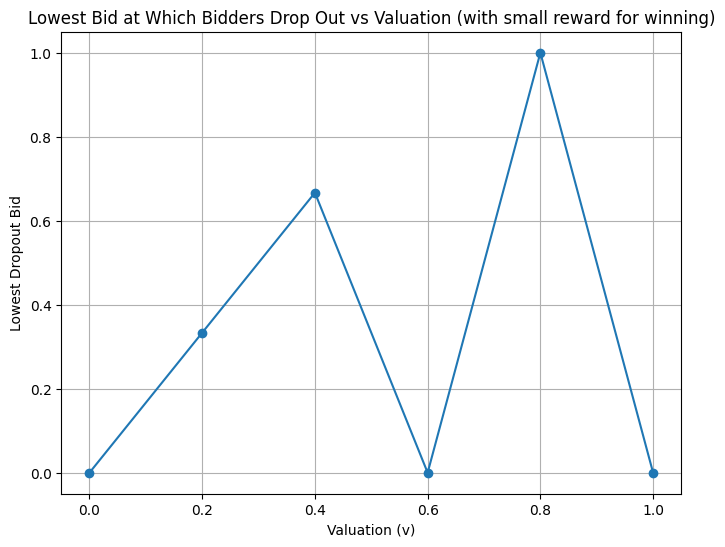

In [86]:
class QLearner:
    def __init__(self, V, K, epsilon=0.99, decay=0.99999, alpha=0.1):
        self.V = V
        self.K = K
        self.epsilon = epsilon
        self.decay = decay
        self.alpha = alpha
        self.q_table = np.random.uniform(0,1,(V, K, 2, 2))  # Q-table: valuations x time steps x active/inactive x actions
    
    def choose_action(self, state):
        if state[2] == 0:  # If the bidder has dropped out, they can only drop out again (action = 0)
            return 0
        if np.random.rand() < self.epsilon:
            return np.random.choice([0, 1])  # Explore
        return np.argmax(self.q_table[state])  # Exploit
    
    def update_q_table(self, state, action, reward, next_state):
        max_next_q = np.max(self.q_table[next_state])
        self.q_table[state + (action,)] += self.alpha * (reward + max_next_q - self.q_table[state + (action,)])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon * self.decay, 0.01)

def run_auction(N, K, V, rounds=100000):
    learners = [QLearner(V, K) for _ in range(N)]
    
    valuation_grid = np.linspace(0, 1, V)  # Create valuation grid
    print(valuation_grid)
    print(np.linspace(0, 1, K))
    
    for r in range(rounds):
        # Draw independent valuations for each bidder and map to nearest grid point
        raw_valuations = np.random.uniform(0, 1, N)
        valuations = np.array([min(valuation_grid, key=lambda x: abs(x - v)) for v in raw_valuations])
        
        bids = np.linspace(0, 1, K)  # Bids as fractions between 0 and 1
        active = [1] * N
        for t in range(K):
            current_bid = bids[t]
            for i, learner in enumerate(learners):
                # Map the valuation to its index in the valuation grid
                v_index = np.argmin(np.abs(valuation_grid - valuations[i]))
                state = (v_index, t, active[i])  # state based on valuation, time period, and active status
                action = learner.choose_action(state)
                
                # If they choose to drop out, their next active state will be 0
                next_active = 0 if action == 0 else active[i]
                next_state = (v_index, t, next_active)
                
                if action == 0:
                    active[i] = 0  # Drop out
                    learner.update_q_table(state, 0, 0, next_state)
                elif np.sum(active) == 1:  # Only one left, they win
                    reward = valuations[i] - current_bid + 0.02  # add small token reward for winning
                    learner.update_q_table(state, 1, reward, next_state)
                    break
                
                if t == K - 1:  # Last round, random winner if multiple left
                    remaining = [i for i, a in enumerate(active) if a == 1]
                    if len(remaining) > 1:
                        winner = random.choice(remaining)
                        v_index_winner = np.argmin(np.abs(valuation_grid - valuations[winner]))
                        reward = valuations[winner] - current_bid + 0.02
                        learners[winner].update_q_table((v_index_winner, t, 1), 1, reward, (v_index_winner, t, 1))
        
        # Learners update their epsilon for exploration
        for learner in learners:
            learner.decay_epsilon()
    
    return learners[0], valuation_grid

# Parameters
V = 6  # number of valuations (split 0-1 into V steps)
K = 4 # number of time periods (split bids from 0-1 into K steps)
N = 2   # number of bidders

# Run the auction simulation with small reward for winning
learner, valuation_grid = run_auction(N, K, V, rounds=500000)

# For each valuation, find the lowest bid at which they drop out
dropout_bids = []

for v in range(V):
    decisions = [np.argmax(learner.q_table[v, t, 1]) for t in range(K)]  # Only consider active bidders (x=1)
    drop_bid = next((t / (K - 1) for t, d in enumerate(decisions) if d == 0), 1.0)  # find the first bid where they drop
    dropout_bids.append(drop_bid)

# Plot the valuations vs the lowest bids at which they drop out
plt.figure(figsize=(8, 6))
plt.plot(valuation_grid, dropout_bids, marker='o')
plt.title('Lowest Bid at Which Bidders Drop Out vs Valuation (with small reward for winning)')
plt.xlabel('Valuation (v)')
plt.ylabel('Lowest Dropout Bid')
plt.grid(True)
plt.show()

In [ ]:
# For each valuation, find the lowest bid at which they drop out
learner, valuation_grid = run_auction_with_avg_reward(N, K, V, rounds=500000)

dropout_bids = []

for v in range(V):
    decisions = [np.argmax(learner.q_table[v, t, 1]) for t in range(K)]  # Only consider active bidders (x=1)
    drop_bid = next((t / (K - 1) for t, d in enumerate(decisions) if d == 0), 1.0)  # find the first bid where they drop
    dropout_bids.append(drop_bid)

# Plot the valuations vs the lowest bids at which they drop out
plt.figure(figsize=(8, 6))
plt.plot(valuation_grid, dropout_bids, marker='o')
plt.title('Lowest Bid at Which Bidders Drop Out vs Valuation (with small reward for winning)')
plt.xlabel('Valuation (v)')
plt.ylabel('Lowest Dropout Bid')
plt.grid(True)
plt.show()


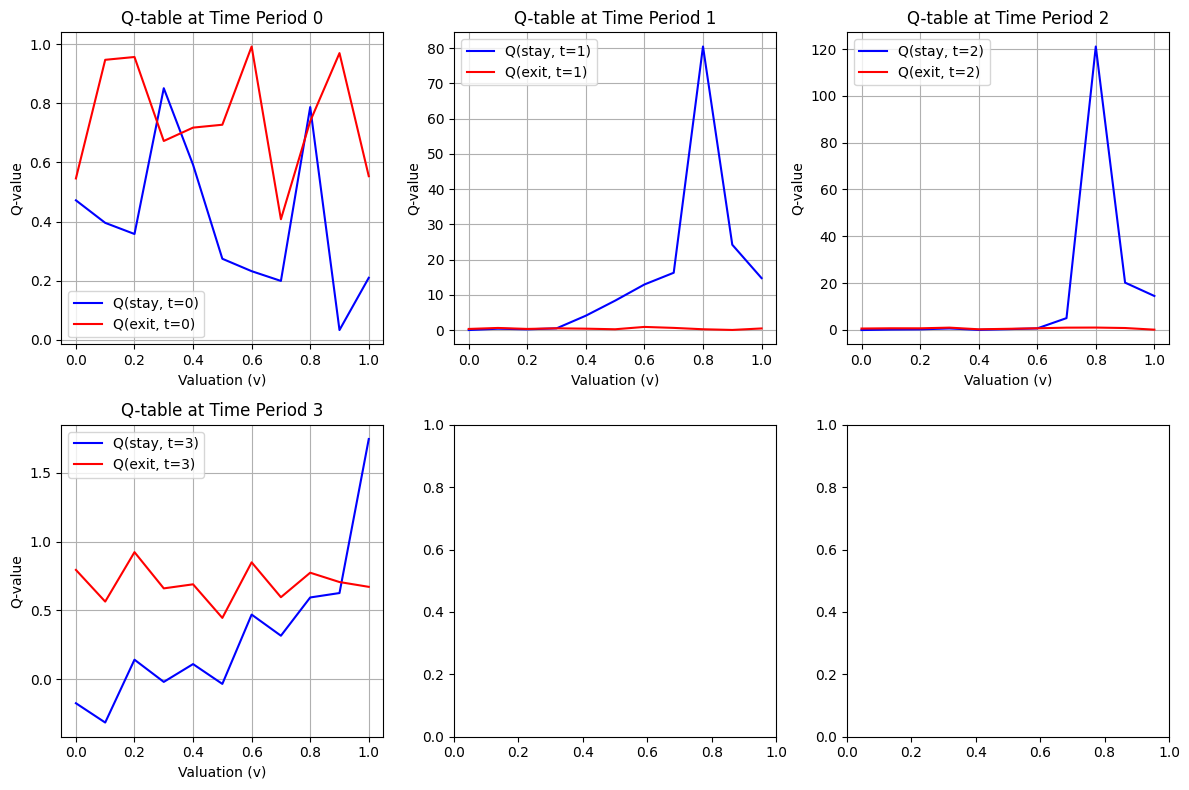

In [84]:
# Visualize both Q-values for "stay" and "exit" for each period
fig, axs = plt.subplots(2, 3, figsize=(12, 8))  # 2x3 grid for 6 periods
axs = axs.flatten()

for t in range(K):
    # Extract Q-values for staying in the auction (action=1) while active (x=1)
    q_values_stay = learner.q_table[:, t, 1, 1]  # Q-values for staying
    q_values_exit = learner.q_table[:, t, 1, 0]  # Q-values for exiting
    
    axs[t].plot(valuation_grid, q_values_stay, label=f'Q(stay, t={t})', color='blue')
    axs[t].plot(valuation_grid, q_values_exit, label=f'Q(exit, t={t})', color='red')
    axs[t].set_xlabel('Valuation (v)')
    axs[t].set_ylabel('Q-value')
    axs[t].set_title(f'Q-table at Time Period {t}')
    axs[t].legend()
    axs[t].grid(True)

plt.tight_layout()
plt.show()


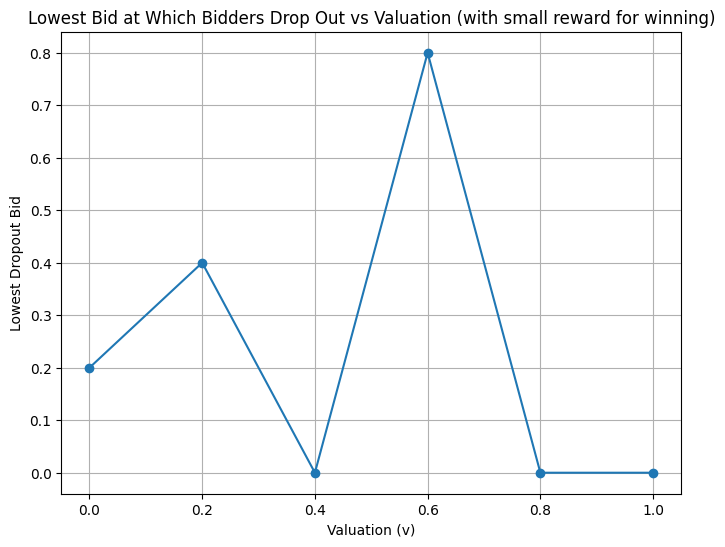

In [91]:
class QLearner:
    def __init__(self, V, K, epsilon=0.99, decay=0.99999, alpha=0.1):
        self.V = V
        self.K = K
        self.epsilon = epsilon
        self.decay = decay
        self.alpha = alpha
        self.q_table = np.random.uniform(0, 1, (V, K, 2))  # Q-table: valuations x time steps x actions (drop out or stay)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice([0, 1])  # Explore
        return np.argmax(self.q_table[state])  # Exploit

    def update_q_table(self, state, action, reward, next_state):
        max_next_q = np.max(self.q_table[next_state])
        self.q_table[state + (action,)] += self.alpha * (reward + max_next_q - self.q_table[state + (action,)])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon * self.decay, 0.01)

def run_auction(N, K, V, rounds=100000):
    learners = [QLearner(V, K) for _ in range(N)]
    valuation_grid = np.linspace(0, 1, V)  # Create valuation grid

    for r in range(rounds):
        # Draw independent valuations for each bidder and map to nearest grid point
        raw_valuations = np.random.uniform(0, 1, N)
        valuations = np.array([min(valuation_grid, key=lambda x: abs(x - v)) for v in raw_valuations])

        bids = np.linspace(0, 1, K)  # Bids as fractions between 0 and 1
        active = [1] * N  # Track whether each bidder is still active

        for t in range(K):
            current_bid = bids[t]
            for i, learner in enumerate(learners):
                if active[i] == 0:
                    continue  # Skip inactive bidders

                # Map the valuation to its index in the valuation grid
                v_index = np.argmin(np.abs(valuation_grid - valuations[i]))
                state = (v_index, t)  # state is simplified: (valuation_index, time_period)
                action = learner.choose_action(state)

                if action == 0:
                    active[i] = 0  # Drop out
                    learner.update_q_table(state, 0, 0, (v_index, t))
                elif np.sum(active) == 1:  # Only one left, they win
                    reward = valuations[i] - current_bid + 0.02  # Small token reward for winning
                    learner.update_q_table(state, 1, reward, (v_index, t))
                    break

            if t == K - 1:  # Last round, random winner if multiple left
                remaining = [i for i, a in enumerate(active) if a == 1]
                if len(remaining) > 1:
                    winner = random.choice(remaining)
                    v_index_winner = np.argmin(np.abs(valuation_grid - valuations[winner]))
                    reward = valuations[winner] - current_bid + 0.02
                    learners[winner].update_q_table((v_index_winner, t), 1, reward, (v_index_winner, t))

        # Learners update their epsilon for exploration
        for learner in learners:
            learner.decay_epsilon()

    return learners[0], valuation_grid

# Parameters
V = 6  # Number of valuations (split 0-1 into V steps)
K = 6   # Number of time periods (split bids from 0-1 into K steps)
N = 2   # Number of bidders

# Run the auction simulation with small reward for winning
learner, valuation_grid = run_auction(N, K, V, rounds=500000)

# For each valuation, find the lowest bid at which they drop out
dropout_bids = []

for v in range(V):
    decisions = [np.argmax(learner.q_table[v, t]) for t in range(K)]
    drop_bid = next((t / (K - 1) for t, d in enumerate(decisions) if d == 0), 1.0)  # Find the first bid where they drop
    dropout_bids.append(drop_bid)

# Plot the valuations vs the lowest bids at which they drop out
plt.figure(figsize=(8, 6))
plt.plot(valuation_grid, dropout_bids, marker='o')
plt.title('Lowest Bid at Which Bidders Drop Out vs Valuation (with small reward for winning)')
plt.xlabel('Valuation (v)')
plt.ylabel('Lowest Dropout Bid')
plt.grid(True)
plt.show()


[0.276 0.685 0.307 0.833 0.283 0.129] 3
[0.276 0.685 0.845 0.833 0.733 0.196] 3
[  0.665  12.124  36.368 246.159 100.11   68.765] 3
[  0.845  12.089  36.117 245.599  99.871  68.053] 3
[1.8900e-01 4.4100e-01 4.8530e+00 3.3070e+02 9.5136e+01 6.8405e+01] 3
[  0.569   0.621   4.671 326.637  92.904  64.227] 3
[ 0.401  0.288  0.523 56.599 56.109 53.749] 3
[ 0.981  0.668  0.703 55.018 52.243 48.687] 3
[-3.0000e-03  1.0600e-01  1.7100e-01  4.5900e-01  6.0410e+00  2.9592e+01] 3
[ 0.776  0.686  0.551  0.639  5.423 25.991] 3
[-0.637 -0.755  0.146  0.253  0.213  3.65 ] 3
[0.294 0.025 0.726 0.633 0.393 3.118] 3


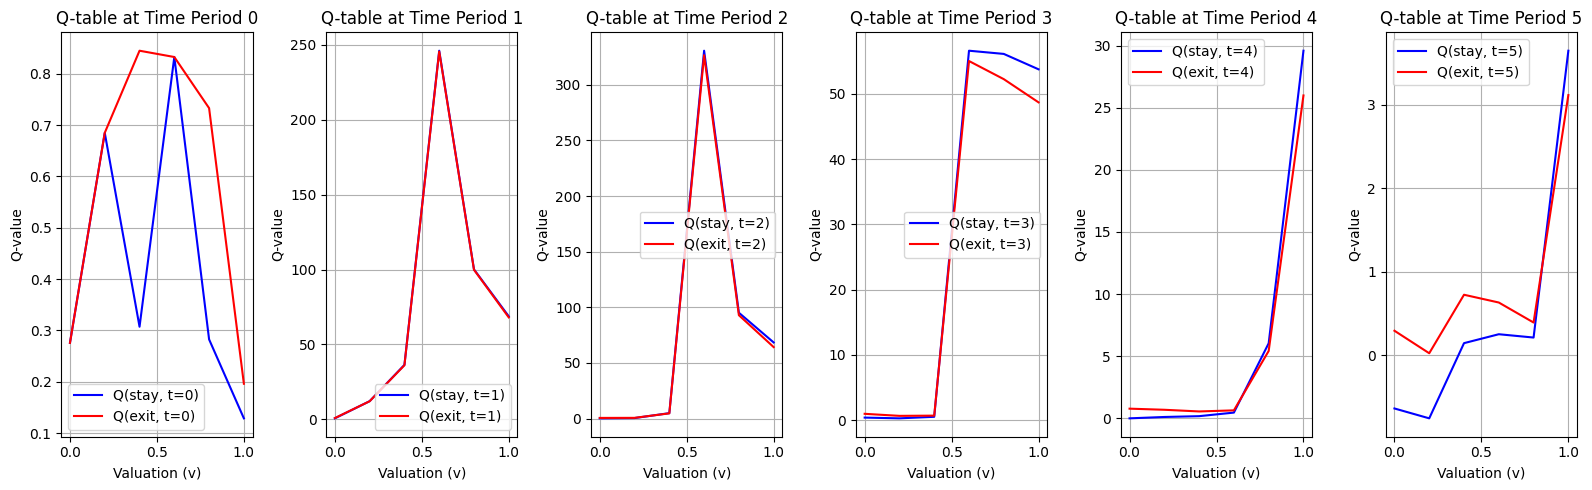

In [96]:
learner_q_table = learner.q_table
# Plot the Q-values for "stay" and "exit" for each time period
fig, axs = plt.subplots(1, K, figsize=(16, 5))  # Adjusted grid for K periods
axs = axs.flatten()

for t in range(K):
    q_values_stay = learner_q_table[:, t, 1]  # Q-values for staying
    q_values_exit = learner_q_table[:, t, 0]  # Q-values for exiting
    print(np.round(q_values_stay,3),3)
    print(np.round(q_values_exit,3),3)

    axs[t].plot(valuation_grid, q_values_stay, label=f'Q(stay, t={t})', color='blue')
    axs[t].plot(valuation_grid, q_values_exit, label=f'Q(exit, t={t})', color='red')
    axs[t].set_xlabel('Valuation (v)')
    axs[t].set_ylabel('Q-value')
    axs[t].set_title(f'Q-table at Time Period {t}')
    axs[t].legend()
    axs[t].grid(True)

plt.tight_layout()
plt.show()

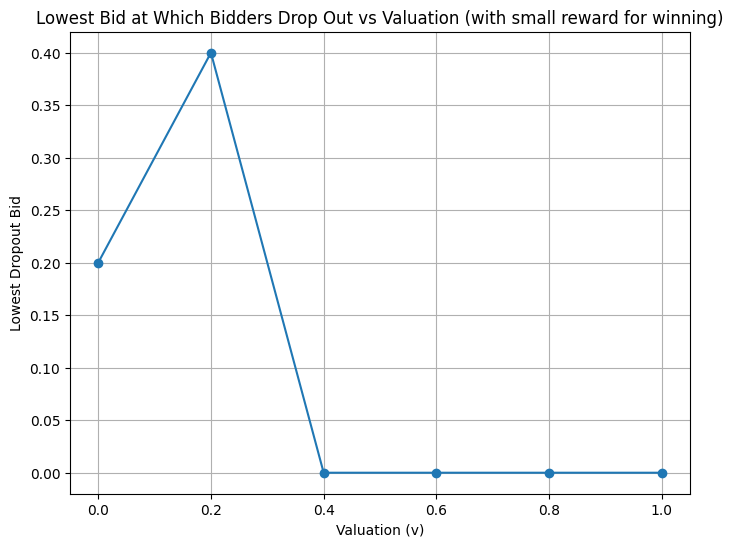

In [98]:
class QLearner:
    def __init__(self, V, K, epsilon=0.99, decay=0.99999, alpha=0.1):
        self.V = V
        self.K = K
        self.epsilon = epsilon
        self.decay = decay
        self.alpha = alpha
        self.q_table = np.random.uniform(0, 1, (V, K, 2))  # Q-table: valuations x time steps x actions (stay, exit)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice([0, 1])  # Explore
        return np.argmax(self.q_table[state])  # Exploit

    def update_q_table(self, state, action, reward, next_state, last_period=False):
        if last_period:
            # Last period: update based on immediate reward, no future state
            self.q_table[state + (action,)] += self.alpha * (reward - self.q_table[state + (action,)])
        else:
            # Non-last period: update based on reward and maximum future Q-value
            max_next_q = np.max(self.q_table[next_state])
            self.q_table[state + (action,)] += self.alpha * (reward + max_next_q - self.q_table[state + (action,)])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon * self.decay, 0.01)

def run_auction(N, K, V, rounds=100000):
    learners = [QLearner(V, K) for _ in range(N)]
    valuation_grid = np.linspace(0, 1, V)  # Create valuation grid

    for r in range(rounds):
        # Draw independent valuations for each bidder and map to nearest grid point
        raw_valuations = np.random.uniform(0, 1, N)
        valuations = np.array([min(valuation_grid, key=lambda x: abs(x - v)) for v in raw_valuations])

        bids = np.linspace(0, 1, K)  # Bids as fractions between 0 and 1
        active = [1] * N  # Track whether each bidder is still active

        for t in range(K):
            current_bid = bids[t]
            for i, learner in enumerate(learners):
                if active[i] == 0:
                    continue  # Skip inactive bidders

                # Map the valuation to its index in the valuation grid
                v_index = np.argmin(np.abs(valuation_grid - valuations[i]))
                state = (v_index, t)  # state is simplified: (valuation_index, time_period)
                action = learner.choose_action(state)

                if action == 0:
                    active[i] = 0  # Drop out
                    learner.update_q_table(state, 0, 0, (v_index, t), last_period=(t == K - 1))
                elif np.sum(active) == 1:  # Only one left, they win
                    reward = valuations[i] - current_bid + 0.02  # Small token reward for winning
                    learner.update_q_table(state, 1, reward, (v_index, t), last_period=(t == K - 1))
                    break

            if t == K - 1:  # Last round, random winner if multiple left
                remaining = [i for i, a in enumerate(active) if a == 1]
                if len(remaining) > 1:
                    winner = random.choice(remaining)
                    v_index_winner = np.argmin(np.abs(valuation_grid - valuations[winner]))
                    reward = valuations[winner] - current_bid + 0.02
                    learners[winner].update_q_table((v_index_winner, t), 1, reward, (v_index_winner, t), last_period=True)

        # Learners update their epsilon for exploration
        for learner in learners:
            learner.decay_epsilon()

    return learners[0], valuation_grid


# Parameters
V = 6  # Number of valuations (split 0-1 into V steps)
K = 6   # Number of time periods (split bids from 0-1 into K steps)
N = 2   # Number of bidders

# Run the auction simulation with small reward for winning
learner, valuation_grid = run_auction(N, K, V, rounds=500000)

# For each valuation, find the lowest bid at which they drop out
dropout_bids = []

for v in range(V):
    decisions = [np.argmax(learner.q_table[v, t]) for t in range(K)]
    drop_bid = next((t / (K - 1) for t, d in enumerate(decisions) if d == 0), 1.0)  # Find the first bid where they drop
    dropout_bids.append(drop_bid)

# Plot the valuations vs the lowest bids at which they drop out
plt.figure(figsize=(8, 6))
plt.plot(valuation_grid, dropout_bids, marker='o')
plt.title('Lowest Bid at Which Bidders Drop Out vs Valuation (with small reward for winning)')
plt.xlabel('Valuation (v)')
plt.ylabel('Lowest Dropout Bid')
plt.grid(True)
plt.show()


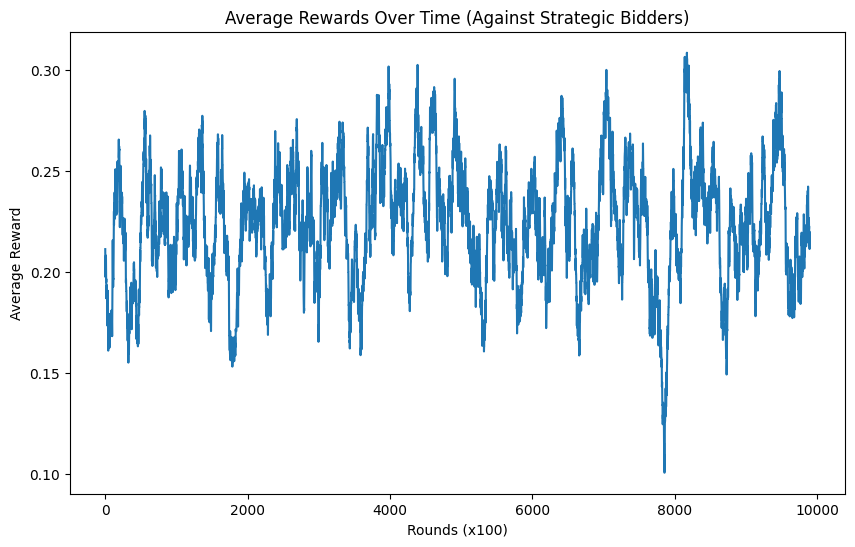

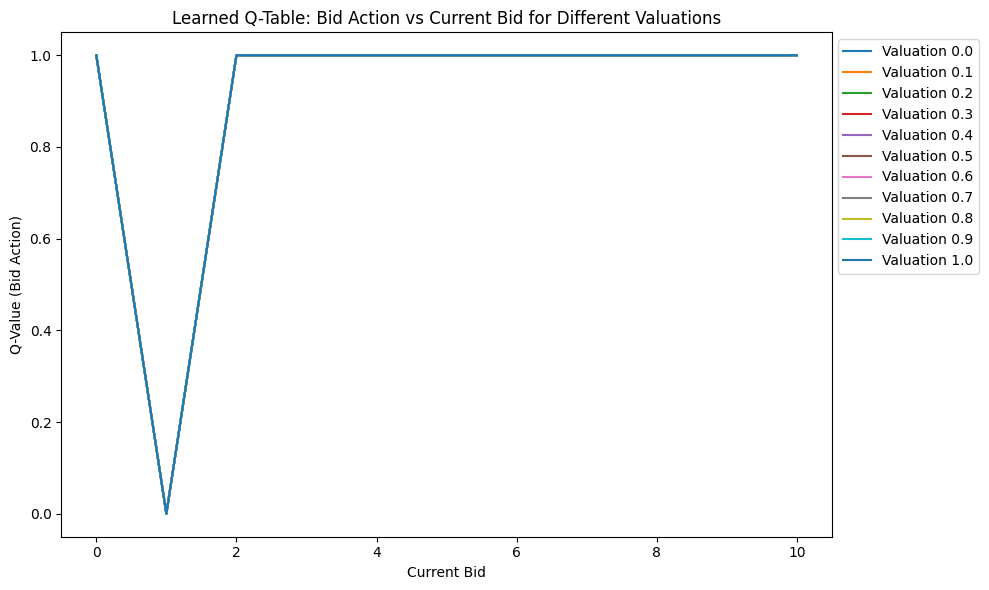

In [8]:
import numpy as np
import matplotlib.pyplot as plt

class QLearningAgentGranular:
    def __init__(self, alpha=0.1, gamma=1, epsilon=0.9, max_bid=11):
        self.q_table = np.ones((max_bid, 2))  # Bid or Pass
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_bid = max_bid
        self.current_bid = 0
        self.valuation = 0

    def set_valuation(self, valuation):
        self.valuation = valuation

    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice([0, 1])  # 0: Pass, 1: Bid
        else:
            return np.argmax(self.q_table[self.current_bid])

    def update_q_value(self, action, reward, terminal=False):
        current_q = self.q_table[self.current_bid, action]
        if terminal:
            self.q_table[self.current_bid, action] += self.alpha * (reward - current_q)
        else:
            next_best_q = np.max(self.q_table[self.current_bid + 1]) if self.current_bid + 1 < self.max_bid else 0
            self.q_table[self.current_bid, action] += self.alpha * (reward + self.gamma * next_best_q - current_q)

    def reset(self):
        self.current_bid = 0


class StrategicBidder:
    def __init__(self, valuation, max_bid=11):
        self.valuation = valuation
        self.current_bid = 0

    def bid(self):
        return self.current_bid < self.valuation


def simulate_auction_strategic(q_agent, strategic_bidders, max_bid=11):
    q_agent.reset()
    auction_ended = False
    current_bid = 0
    while not auction_ended:
        action = q_agent.choose_action()  # 0: Pass, 1: Bid
        if action == 0 or current_bid >= q_agent.valuation:
            auction_ended = True
            reward = 0 if current_bid >= q_agent.valuation else q_agent.valuation - current_bid * 0.1
            q_agent.update_q_value(action, reward, terminal=True)
            return current_bid, reward, False  # lost auction
        else:
            current_bid += 1
            for bidder in strategic_bidders:
                bidder.current_bid = current_bid
                if not bidder.bid():
                    strategic_bidders.remove(bidder)
            if len(strategic_bidders) == 0:
                reward = q_agent.valuation - current_bid * 0.1
                q_agent.update_q_value(action, reward, terminal=True)
                return current_bid, reward, True  # won auction
            q_agent.current_bid = current_bid


def simulate_and_track_rewards(q_agent, num_rounds=10000, num_bidders=5, max_bid=11):
    avg_rewards = []
    rewards = []
    for _ in range(num_rounds):
        # Set agent's valuation and bidders' valuations for this round
        q_agent.set_valuation(np.random.uniform(0, 1))
        strategic_bidders = [StrategicBidder(np.random.uniform(0, 1)) for _ in range(num_bidders)]

        _, reward, _ = simulate_auction_strategic(q_agent, strategic_bidders)
        rewards.append(reward)
        if len(rewards) > 100:
            avg_rewards.append(np.mean(rewards[-100:]))
    return avg_rewards


def plot_q_table(q_agent, max_bid=11):
    fig, ax = plt.subplots(figsize=(10, 6))
    for v in range(max_bid):
        ax.plot(q_agent.q_table[:max_bid, 1], label=f'Valuation {v * 0.1:.1f}')
    ax.set_xlabel('Current Bid')
    ax.set_ylabel('Q-Value (Bid Action)')
    ax.set_title('Learned Q-Table: Bid Action vs Current Bid for Different Valuations')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()


# Initialize agent
n_random_bidders = 1
q_agent_granular = QLearningAgentGranular()

# Run simulation and track rewards
avg_rewards = simulate_and_track_rewards(q_agent_granular)

# Plot average rewards over time
plt.figure(figsize=(10, 6))
plt.plot(avg_rewards)
plt.xlabel('Rounds (x100)')
plt.ylabel('Average Reward')
plt.title('Average Rewards Over Time (Against Strategic Bidders)')
plt.show()

# Plot the Q-table
plot_q_table(q_agent_granular)


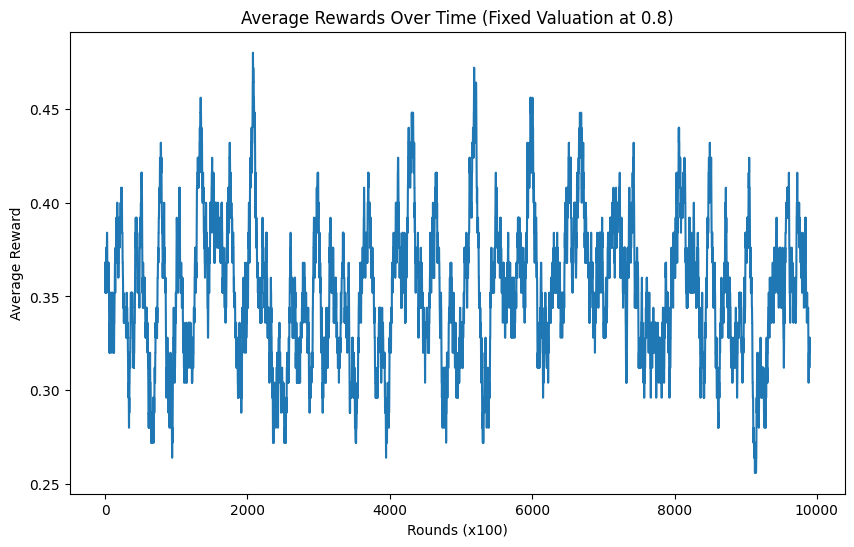

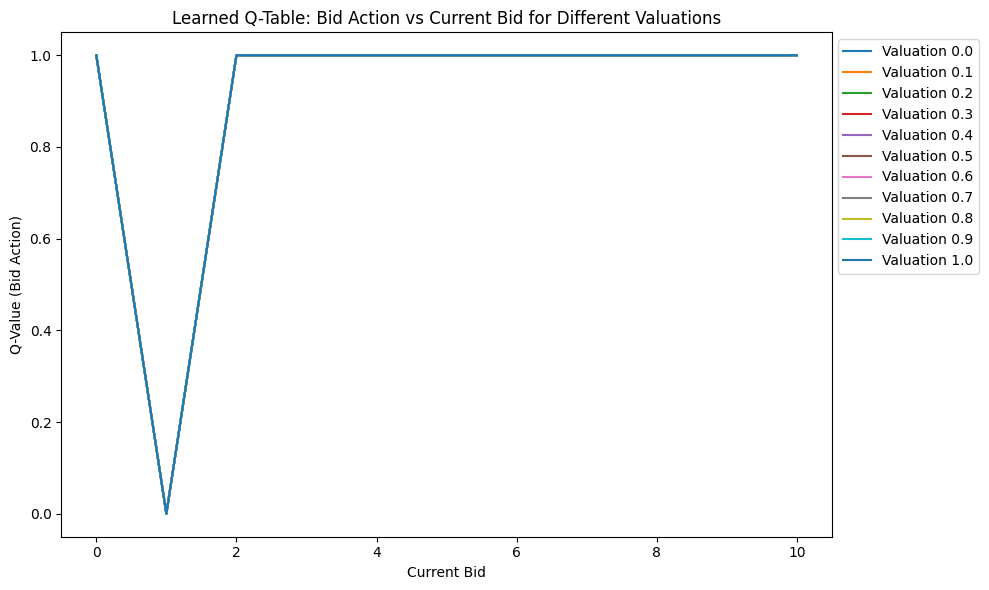

In [9]:
def simulate_auction_strategic_fixed(q_agent, strategic_bidders, max_bid=11):
    q_agent.reset()
    auction_ended = False
    current_bid = 0
    while not auction_ended:
        action = q_agent.choose_action()  # 0: Pass, 1: Bid
        if action == 0 or current_bid >= q_agent.valuation:
            auction_ended = True
            reward = 0 if current_bid >= q_agent.valuation else q_agent.valuation - current_bid * 0.1
            q_agent.update_q_value(action, reward, terminal=True)
            return current_bid, reward, False  # lost auction
        else:
            current_bid += 1
            for bidder in strategic_bidders:
                bidder.current_bid = current_bid
                if not bidder.bid():
                    strategic_bidders.remove(bidder)
            if len(strategic_bidders) == 0:
                reward = q_agent.valuation - current_bid * 0.1
                q_agent.update_q_value(action, reward, terminal=True)
                return current_bid, reward, True  # won auction
            q_agent.current_bid = current_bid

def simulate_and_track_rewards_with_fixed_valuation(q_agent, num_rounds=10000, num_bidders=5, max_bid=11):
    avg_rewards = []
    rewards = []
    q_agent.set_valuation(0.8)  # Fixing the agent's valuation at 0.8
    for _ in range(num_rounds):
        strategic_bidders = [StrategicBidder(np.random.uniform(0, 1)) for _ in range(num_bidders)]
        _, reward, _ = simulate_auction_strategic_fixed(q_agent, strategic_bidders)
        rewards.append(reward)
        if len(rewards) > 100:
            avg_rewards.append(np.mean(rewards[-100:]))
    return avg_rewards


# Initialize agent
q_agent_granular_fixed = QLearningAgentGranular()

# Run simulation with fixed valuation and track rewards
avg_rewards_fixed = simulate_and_track_rewards_with_fixed_valuation(q_agent_granular_fixed)

# Plot average rewards over time
plt.figure(figsize=(10, 6))
plt.plot(avg_rewards_fixed)
plt.xlabel('Rounds (x100)')
plt.ylabel('Average Reward')
plt.title('Average Rewards Over Time (Fixed Valuation at 0.8)')
plt.show()

# Plot the Q-table after fixed valuation learning
plot_q_table(q_agent_granular_fixed)
